In [1]:
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
from pydynamics.process_models import FOPDT

In [2]:
data = pd.read_csv('CNS_MAP.csv', low_memory=False)

In [3]:
y1 = data['PscO2'].values
u1 = data['MAP'].values
u2 = data['HR(nonin)'].values

# Zero-correct the signals
y1 -= y1[0]
u1 -= u1[0]
u2 -= u2[0]

# Decimate

y1d = signal.decimate(y1, 60)
u1d = signal.decimate(u1, 60)
u2d = signal.decimate(u2, 60)

d = np.vstack((y1d, u1d, u2d))

# Time vector

# Filter
b, a = signal.butter(2, 0.1, 'low', fs=1)

# Get back the three timeseries
y1f, u1f, u2f = signal.filtfilt(b, a, d[:,:50], axis=1)
t = np.arange(len(y1f))

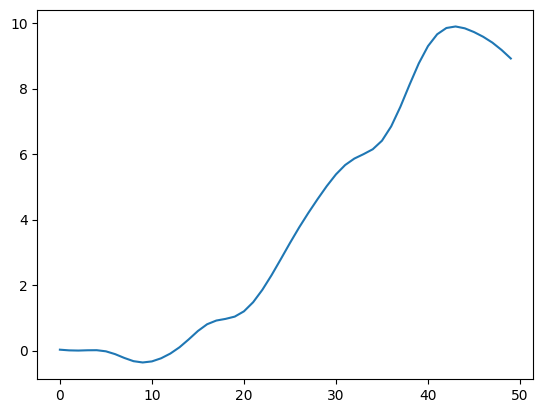

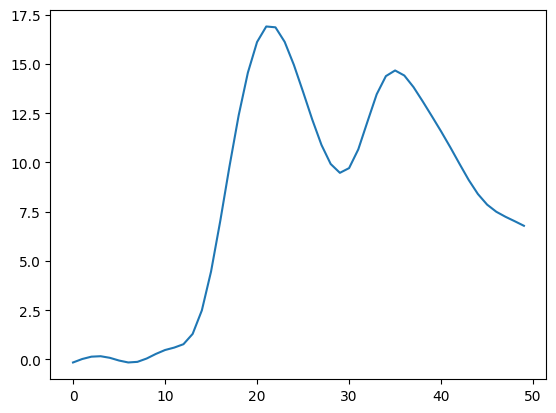

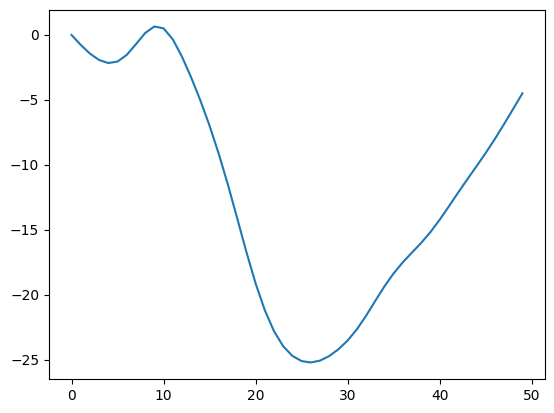

In [4]:
plt.plot(t, y1f)
plt.figure()
plt.plot(t, u1f)
plt.figure()
plt.plot(t, u2f)

In [5]:
fom = FOPDT(t, y1f, u1f, u2f)
res = fom.fit_model()

KS Test of Residuals: p=0.010


In [7]:
print(res.p_opt)
print(res.r_square)

[1.32647082 3.40374567 7.16877456 0.15494269 3.40965715 0.        ]
{'marginal': np.float64(0.8201190508510636), 'conditional': [np.float64(0.7511230045746655), np.float64(-0.2173836744277009)]}


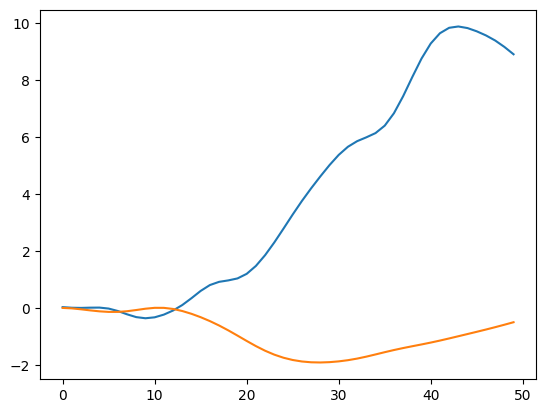

In [9]:
zeros = np.zeros((len(t)))
y_u2 = fom.simulate(res.p_opt, t, zeros, u2f)
plt.plot(y1f)
plt.plot(y_u2)

In [11]:
# Try a different filter
b, a = signal.butter(2, 0.2, 'low', fs=1)

# Get back the three timeseries
y1f, u1f, u2f = signal.filtfilt(b, a, d[:,:50], axis=1)
t = np.arange(len(y1f))

fom = FOPDT(t, y1f, u1f, u2f)
res = fom.fit_model()

print(res.p_opt)
print(res.r_square)

KS Test of Residuals: p=0.583
[ 0.99015217 16.27048637 18.54144445 -0.55208458 15.43871602  1.9750869 ]
{'marginal': np.float64(0.9909568270712068), 'conditional': [np.float64(0.6094730045251802), np.float64(0.7178267749287587)]}


In [10]:
# Try a different filter
b, a = signal.butter(2, 0.4, 'low', fs=1)

# Get back the three timeseries
y1f, u1f, u2f = signal.filtfilt(b, a, d[:,:50], axis=1)
t = np.arange(len(y1f))

fom = FOPDT(t, y1f, u1f, u2f)
res = fom.fit_model()

print(res.p_opt)
print(res.r_square)

KS Test of Residuals: p=0.373
[ 1.06960133 13.94225507 19.0950741  -0.46530562 10.45774273  2.77821563]
{'marginal': np.float64(0.9872044982652894), 'conditional': [np.float64(0.6196285960994369), np.float64(0.6898091849998137)]}
